In [1]:
import pandas as pd
import numpy as np
import os

os.chdir('../')

In [2]:
%pwd

'/media/om/volume2/MLOPS/The Ultimate MLOPS Course/youtube_project/MLOPS_youtube_CTA_Project'

## 1. data ingestion

In [3]:
df= pd.read_csv("./data/raw/youtube_10000_videos.csv")
df.head()

,category,channel_id,channel_name,subscriber_count,channel_view_count,channel_video_count,video_id,video_title,published_at,duration_seconds,view_count,like_count,comment_count,description,video_url
0,Education,UCBg_mociSFb4ECbu91_cXJA,ABHYAAS EDUCATION,167000,5169057,1711,MOlaKBJ1nDA,प्रश्नावली 5.2 Class 10 Maths | NCERT Class 10...,2026-07-18T01:52:16Z,3988.0,427,21,3,📚 Class 10 Maths Chapter 5 – Arithmetic Progre...,https://www.youtube.com/watch?v=MOlaKBJ1nDA
1,Education,UCBg_mociSFb4ECbu91_cXJA,ABHYAAS EDUCATION,167000,5169057,1711,uXRH_uqCOXI,प्रश्नावली 5.3 Class 10 Maths | NCERT Class 10...,2026-07-19T02:22:39Z,3606.0,528,32,2,📚 Class 10 Maths Chapter 5 – Arithmetic Progre...,https://www.youtube.com/watch?v=uXRH_uqCOXI
2,Education,UCBg_mociSFb4ECbu91_cXJA,ABHYAAS EDUCATION,167000,5169057,1711,q4Q4dg6JDE0,प्रश्नावली 5.3 Class 10 Maths | NCERT Class 10...,2026-07-22T01:57:46Z,3985.0,520,23,2,📚 Class 10 Maths Chapter 5 – Arithmetic Progre...,https://www.youtube.com/watch?v=q4Q4dg6JDE0
3,Education,UCBg_mociSFb4ECbu91_cXJA,ABHYAAS EDUCATION,167000,5169057,1711,UTrN2vvjau8,Class 10 Maths | निर्देशांक ज्यामिति (Coordina...,2026-07-23T01:56:33Z,4655.0,566,27,0,Class 10 Maths | Coordinate Geometry Part 01 |...,https://www.youtube.com/watch?v=UTrN2vvjau8
4,Education,UCBg_mociSFb4ECbu91_cXJA,ABHYAAS EDUCATION,167000,5169057,1711,22S8ptzHl-g,Class 10 Maths | निर्देशांक ज्यामिति (Coordina...,2026-07-24T02:38:43Z,2185.0,355,23,3,Class 10 Maths | Coordinate Geometry Part 01 |...,https://www.youtube.com/watch?v=22S8ptzHl-g


# 2. Data cleaning

In [4]:
df.isnull().sum()

category                 0
channel_id               0
channel_name             0
subscriber_count         0
channel_view_count       0
channel_video_count      0
video_id                 0
video_title              0
published_at             0
duration_seconds         6
view_count               0
like_count               0
comment_count            0
description            988
video_url                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9955 entries, 0 to 9954
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   category             9955 non-null   object 
 1   channel_id           9955 non-null   object 
 2   channel_name         9955 non-null   object 
 3   subscriber_count     9955 non-null   int64  
 4   channel_view_count   9955 non-null   int64  
 5   channel_video_count  9955 non-null   int64  
 6   video_id             9955 non-null   object 
 7   video_title          9955 non-null   object 
 8   published_at         9955 non-null   object 
 9   duration_seconds     9949 non-null   float64
 10  view_count           9955 non-null   int64  
 11  like_count           9955 non-null   int64  
 12  comment_count        9955 non-null   int64  
 13  description          8967 non-null   object 
 14  video_url            9955 non-null   object 
dtypes: float64(1), int64(6), object(8)
mem

## required columns

In [6]:
columns_all=df.columns
columns_all

Index(['category', 'channel_id', 'channel_name', 'subscriber_count',
       'channel_view_count', 'channel_video_count', 'video_id', 'video_title',
       'published_at', 'duration_seconds', 'view_count', 'like_count',
       'comment_count', 'description', 'video_url'],
      dtype='object')

In [7]:
columns1= ['category', 'subscriber_count','channel_view_count', 'channel_video_count','duration_seconds', 'view_count']
df1=df[columns1]
df1

,category,subscriber_count,channel_view_count,channel_video_count,duration_seconds,view_count
0,Education,167000,5169057,1711,3988.0,427
1,Education,167000,5169057,1711,3606.0,528
2,Education,167000,5169057,1711,3985.0,520
3,Education,167000,5169057,1711,4655.0,566
4,Education,167000,5169057,1711,2185.0,355
...,...,...,...,...,...,...
9950,Travel,127000,18680974,219,3719.0,66816
9951,Travel,127000,18680974,219,4181.0,232027
9952,Travel,127000,18680974,219,3743.0,85656
9953,Travel,127000,18680974,219,22.0,147597


In [8]:
df1.isnull().sum()

category               0
subscriber_count       0
channel_view_count     0
channel_video_count    0
duration_seconds       6
view_count             0
dtype: int64

In [9]:
df1.dropna(inplace=True)
df1.isnull().sum().sum()

/tmp/ipykernel_26596/3203993292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.dropna(inplace=True)


np.int64(0)

In [10]:
all_columns=df1.columns
all_columns

Index(['category', 'subscriber_count', 'channel_view_count',
       'channel_video_count', 'duration_seconds', 'view_count'],
      dtype='object')

In [11]:
numeric_columns= list(all_columns[1:])
numeric_columns

['subscriber_count',
 'channel_view_count',
 'channel_video_count',
 'duration_seconds',
 'view_count']

In [12]:
def removing_zero_values(df:pd.DataFrame,columns:list[str])->pd.DataFrame:
    df_cleaned= df.copy()
    for column in columns:
        df_cleaned=df_cleaned[df_cleaned[column]>0]
    print("Rows removed: ",len(df)-len(df_cleaned)) 
    print("% of Rows removed: ",(len(df)-len(df_cleaned))*100/len(df))   
    return df_cleaned.reset_index(drop=True) 

df1= removing_zero_values(df1,numeric_columns)   
df1

Rows removed:  107
% of Rows removed:  1.0754849733641572


,category,subscriber_count,channel_view_count,channel_video_count,duration_seconds,view_count
0,Education,167000,5169057,1711,3988.0,427
1,Education,167000,5169057,1711,3606.0,528
2,Education,167000,5169057,1711,3985.0,520
3,Education,167000,5169057,1711,4655.0,566
4,Education,167000,5169057,1711,2185.0,355
...,...,...,...,...,...,...
9837,Travel,127000,18680974,219,3719.0,66816
9838,Travel,127000,18680974,219,4181.0,232027
9839,Travel,127000,18680974,219,3743.0,85656
9840,Travel,127000,18680974,219,22.0,147597


# 3.Data exploration

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt 

<Axes: xlabel='subscriber_count', ylabel='Density'>

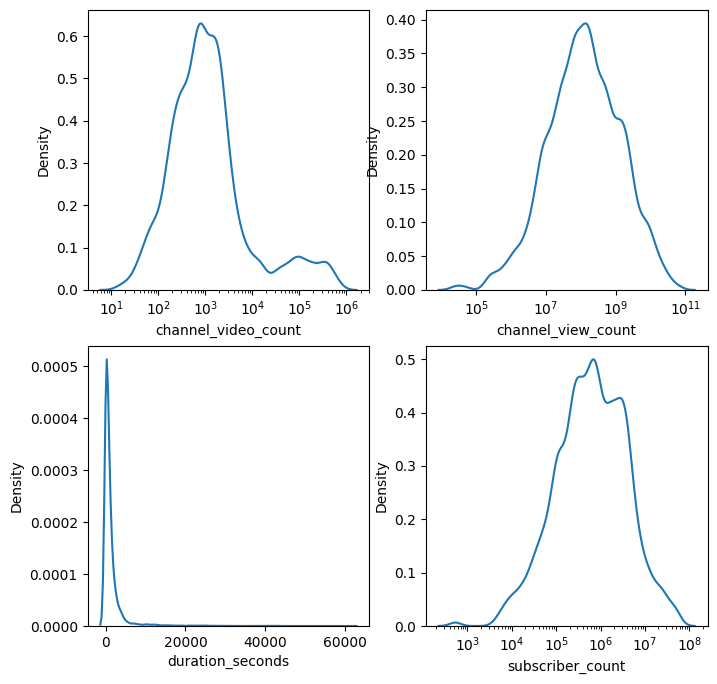

In [14]:
plt.figure(figsize=(8,8))
# equivalent but more general
ax1 = plt.subplot(221)
sns.kdeplot(df1["channel_video_count"],log_scale=True)
# add a subplot with no frame
ax2 = plt.subplot(222)
sns.kdeplot(df1["channel_view_count"],log_scale=True)
# equivalent but more general
ax3 = plt.subplot(223)
sns.kdeplot(df1["duration_seconds"])
# add a subplot with no frame
ax4 = plt.subplot(224)
sns.kdeplot(df1["subscriber_count"],log_scale=True)

<Axes: ylabel='subscriber_count'>

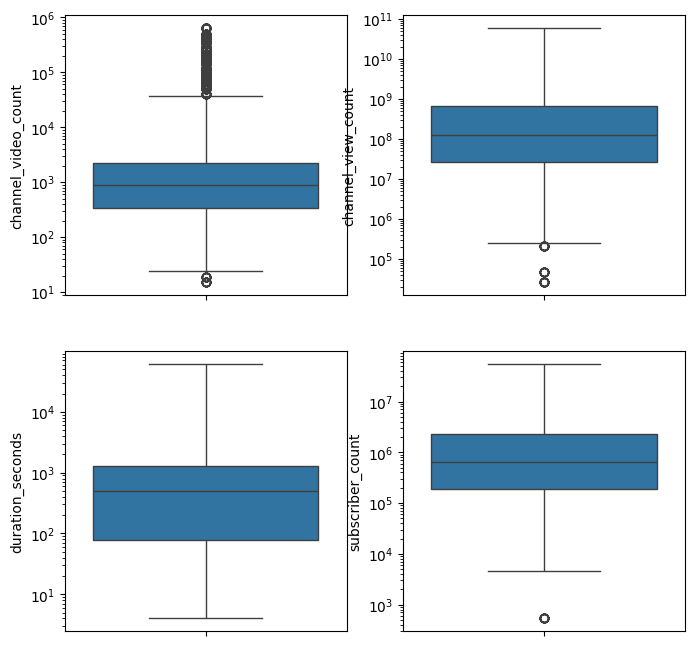

In [15]:
plt.figure(figsize=(8,8))
# equivalent but more general
ax1 = plt.subplot(221)
sns.boxplot(df1["channel_video_count"],log_scale=True)
# add a subplot with no frame
ax2 = plt.subplot(222)
sns.boxplot(df1["channel_view_count"],log_scale=True)
# equivalent but more general
ax3 = plt.subplot(223)
sns.boxplot(df1["duration_seconds"],log_scale=True)
# add a subplot with no frame
ax4 = plt.subplot(224)
sns.boxplot(df1["subscriber_count"],log_scale=True)

<Axes: ylabel='view_count'>

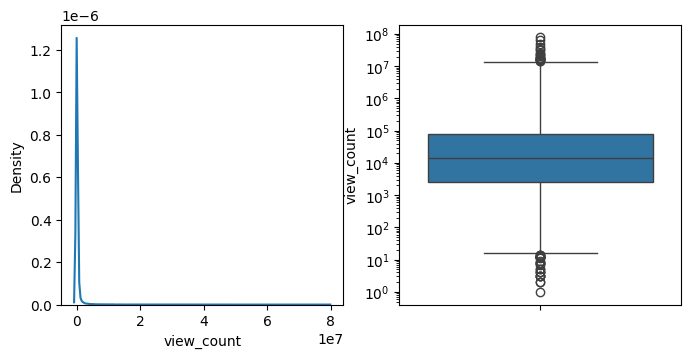

In [16]:
plt.figure(figsize=(8,8))
ax1 = plt.subplot(221)
sns.kdeplot(df1["view_count"])

ax1 = plt.subplot(222)
sns.boxplot(df1["view_count"],log_scale=True)

# 4. Feature engineering

In [ ]:
# removing the outliers using IQR method
def remove_outliers(df:pd.DataFrame,columns: list[str])->pd.DataFrame:
    """ Removing outliers using IQR method."""
    df_cleaned= df.copy()
    for column in columns:
        q1= df_cleaned[column].quantile(0.25)
        q3= df_cleaned[column].quantile(0.75)
        
        iqr= q3-q1
        
        lower_bound= q1-1.5*iqr
        upper_bound= q3+1.5*iqr
        
        df_cleaned=df_cleaned[df_cleaned[column].between(lower_bound,upper_bound)]
    print("Rows removed: ",len(df)-len(df_cleaned)) 
    print("% of Rows removed: ",(len(df)-len(df_cleaned))*100/len(df)) 
    
    return df_cleaned.reset_index(drop=True)

In [18]:
# df2= remove_outliers(df1,numeric_columns)
# df2

In [19]:
# plt.figure(figsize=(8,8))
# # equivalent but more general
# ax1 = plt.subplot(221)
# sns.kdeplot(df2["channel_video_count"],log_scale=True)
# # add a subplot with no frame
# ax2 = plt.subplot(222)
# sns.kdeplot(df2["channel_view_count"],log_scale=True)
# # equivalent but more general
# ax3 = plt.subplot(223)
# sns.kdeplot(df2["duration_seconds"])
# # add a subplot with no frame
# ax4 = plt.subplot(224)
# sns.kdeplot(df2["subscriber_count"],log_scale=True)

In [20]:
# plt.figure(figsize=(8,8))
# # equivalent but more general
# ax1 = plt.subplot(221)
# sns.boxplot(df2["channel_video_count"],log_scale=True)
# # add a subplot with no frame
# ax2 = plt.subplot(222)
# sns.boxplot(df2["channel_view_count"],log_scale=True)
# # equivalent but more general
# ax3 = plt.subplot(223)
# sns.boxplot(df2["duration_seconds"],log_scale=True)
# # add a subplot with no frame
# ax4 = plt.subplot(224)
# sns.boxplot(df2["subscriber_count"],log_scale=True)

In [21]:
# plt.figure(figsize=(8,8))
# ax1 = plt.subplot(221)
# sns.kdeplot(df2["view_count"])

# ax1 = plt.subplot(222)
# sns.boxplot(df2["view_count"],log_scale=True)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np

numeric_features = [
    "subscriber_count",
    "channel_view_count",
    "channel_video_count",
    "duration_seconds",
]

categorical_features = ["category"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log_transform", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=2000,
            random_state=42,
            n_jobs=-1
        )),
    ]
)

In [23]:
X=df1.drop(columns=["view_count"])
X

,category,subscriber_count,channel_view_count,channel_video_count,duration_seconds
0,Education,167000,5169057,1711,3988.0
1,Education,167000,5169057,1711,3606.0
2,Education,167000,5169057,1711,3985.0
3,Education,167000,5169057,1711,4655.0
4,Education,167000,5169057,1711,2185.0
...,...,...,...,...,...
9837,Travel,127000,18680974,219,3719.0
9838,Travel,127000,18680974,219,4181.0
9839,Travel,127000,18680974,219,3743.0
9840,Travel,127000,18680974,219,22.0


In [24]:
y=np.log1p(df1["view_count"])
y

0        6.059123
1        6.270988
2        6.255750
3        6.340359
4        5.874931
          ...    
9837    11.109713
9838    12.354613
9839    11.358106
9840    11.902248
9841    12.598442
Name: view_count, Length: 9842, dtype: float64

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_pipeline.fit(X_train, y_train)

predictions = model_pipeline.predict(X_test)

In [26]:
predictions

array([ 5.46626955, 13.06277245,  6.30186922, ...,  7.92955239,
       10.02355516, 11.14753732], shape=(1969,))

In [27]:
y_test

7988     4.553877
7120    13.939965
106      6.242223
439      3.218876
2420     8.435115
          ...    
1452    11.403936
101      7.580189
319      7.741968
2692     9.689985
4352    11.800710
Name: view_count, Length: 1969, dtype: float64

In [28]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred= model_pipeline.predict(X_test)
r2= r2_score(y_test,y_pred)
r2

0.7966643614620904